In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import ( f1_score,  balanced_accuracy_score
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from collections import Counter

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Memory-efficient version, only pull columns needed for feature engineering
usecols = [
    "year", "PUMA", "POVPIP", "AGEP",
    "SCHL", "HISP", "RAC1P",
    "RACWHT", "RACBLK", "RACASN", "RACAIAN", "RACNH", "RACPI", "RACSOR",
    "HICOV", "PRIVCOV", "PUBCOV",
    "DEAR", "DEYE", "DREM", "DPHY", "DDRS", "DOUT",
    "ENG", "LANX", "ESR", "WRK", "WKHP", "OCCP",
    "DIS", "CIT", "MAR", "MSP", "NATIVITY", "SEX", "MIG", "WKL",
    "COW", "SCH",
]

path = "../1_Raw_Data/data_persons_ca_1yr/persons_master.csv"

df = pd.read_csv(
    path,
    usecols=lambda c: c in set(usecols),
    low_memory=False
)

print(f"Raw (subset) shape: {df.shape}")
print(f"Years present: {sorted(df['year'].unique())}")
print(f"Age range: {df['AGEP'].min()} - {df['AGEP'].max()}")

Raw (subset) shape: (1874943, 39)
Years present: [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Age range: 18 - 94


In [3]:
def categorize_poverty_score(val):
    if pd.isna(val): return None
    if val <= 50: return 3      # Deep Poverty
    if val <= 100: return 2     # Poverty
    if val <= 200: return 1     # Near Poverty
    return 0                    # Stable

df['poverty_risk_score'] = df['POVPIP'].apply(categorize_poverty_score)
df = df.dropna(subset=['poverty_risk_score'])
df['poverty_risk_score'] = df['poverty_risk_score'].astype(int)
df['binary_target'] = (df['poverty_risk_score'] > 0).astype(int)

print('Target distribution (4-class):')
print(df['poverty_risk_score'].value_counts().sort_index())
print(f'\nBinary target distribution:')
print(df['binary_target'].value_counts())

Target distribution (4-class):
poverty_risk_score
0    1364781
1     239609
2      96365
3      98017
Name: count, dtype: int64

Binary target distribution:
binary_target
0    1364781
1     433991
Name: count, dtype: int64


In [4]:
def map_puma_to_region(puma):
    if pd.isna(puma): return 'Unknown'
    p = int(puma)
    if p < 1500: return 'Northern CA/Sierras'
    if 1500 <= p < 3000: return 'Bay Area'
    if 3000 <= p < 5000: return 'Central Valley'
    if 5000 <= p < 7000: return 'Central Coast'
    if 7000 <= p < 9000: return 'Los Angeles'
    if 9000 <= p < 10000: return 'Inland Empire'
    if p >= 10000: return 'San Diego/Border'
    return 'Unknown'

df['CA_Region'] = df['PUMA'].apply(map_puma_to_region)
print('Region distribution:')
print(df['CA_Region'].value_counts())

Region distribution:
CA_Region
Central Valley         518051
Los Angeles            494615
Central Coast          378990
Northern CA/Sierras    157684
Bay Area               104317
San Diego/Border        78341
Inland Empire           66774
Name: count, dtype: int64


## 1) Disability Aggregate

Sum of 6 individual disability indicators → severity score (0-6)

In [5]:
disability_cols = ['DEAR', 'DEYE', 'DPHY', 'DREM', 'DDRS', 'DOUT']
for col in disability_cols:
    print(f'{col}: {df[col].value_counts().sort_index().to_dict()}')

DEAR: {1: 76691, 2: 1722081}
DEYE: {1: 47074, 2: 1751698}
DPHY: {1.0: 137631, 2.0: 1661141}
DREM: {1.0: 94844, 2.0: 1703928}
DDRS: {1.0: 59976, 2.0: 1738796}
DOUT: {1.0: 113708, 2.0: 1685064}


In [6]:
for col in disability_cols:
    df[f'{col}_binary'] = (df[col] == 1).astype(int)
df['disability_score'] = df[[f'{c}_binary' for c in disability_cols]].sum(axis=1)

print('Disability severity score distribution:')
print(df['disability_score'].value_counts().sort_index())
print(f'Correlation with poverty_risk_score: {df["disability_score"].corr(df["poverty_risk_score"]):.4f}')
print(f'Correlation with POVPIP: {df["disability_score"].corr(df["POVPIP"]):.4f}')
print(f'Original DIS correlation with POVPIP: {(df["DIS"] == 1).astype(int).corr(df["POVPIP"]):.4f}')

Disability severity score distribution:
disability_score
0    1534797
1     130944
2      56935
3      37188
4      25117
5       9668
6       4123
Name: count, dtype: int64
Correlation with poverty_risk_score: 0.1380
Correlation with POVPIP: -0.1551
Original DIS correlation with POVPIP: -0.1503


## 2) Health Insurance Collapse

Single binary: has any insurance (1) vs. no insurance (0)

In California, Medi-Cal qualification requires being at or below the poverty line. Keeping PRIVCOV/PUBCOV separately may introduce quasi-data-leakage since public insurance status is essentially a proxy for poverty status.

In [7]:
print('HICOV (any insurance):', df['HICOV'].value_counts().sort_index().to_dict())
print('PRIVCOV (private):', df['PRIVCOV'].value_counts().sort_index().to_dict())
print('PUBCOV (public):', df['PUBCOV'].value_counts().sort_index().to_dict())

HICOV (any insurance): {1: 1682200, 2: 116572}
PRIVCOV (private): {1: 1201899, 2: 596873}
PUBCOV (public): {1: 732114, 2: 1066658}


In [8]:
df['has_insurance'] = (df['HICOV'] == 1).astype(int)
print('has_insurance distribution:')
print(df['has_insurance'].value_counts())
print(f'Correlation with POVPIP: {df["has_insurance"].corr(df["POVPIP"]):.4f}')
print(f'has_insurance (new):  {df["has_insurance"].corr(df["POVPIP"]):.4f}')
print(f'PRIVCOV (old):        {(df["PRIVCOV"] == 1).astype(int).corr(df["POVPIP"]):.4f}')
print(f'PUBCOV (old):         {(df["PUBCOV"] == 1).astype(int).corr(df["POVPIP"]):.4f}')
print(f'HICOV (old):          {(df["HICOV"] == 1).astype(int).corr(df["POVPIP"]):.4f}')

has_insurance distribution:
has_insurance
1    1682200
0     116572
Name: count, dtype: int64
Correlation with POVPIP: 0.1557
has_insurance (new):  0.1557
PRIVCOV (old):        0.4344
PUBCOV (old):         -0.2940
HICOV (old):          0.1557


## 3) Race / Ethnicity Encoding

1. Collapse to 5 race categories: White, Black, Asian, Indigenous, Other
2. Add `HISP` as binary Latinx ethnicity indicator
3. One-hot encode the 5 race categories
4. Create racial-ethnic aggregate (sum → captures multiracial identities)

In [9]:
race_binary_cols = ['RACWHT', 'RACBLK', 'RACASN', 'RACAIAN', 'RACNH', 'RACPI', 'RACSOR']
print('Individual race flag distributions:')
for col in race_binary_cols:
    print(f'  {col}: {df[col].value_counts().sort_index().to_dict()}')
print(f'HISP == 1 (Not Hispanic): {(df["HISP"] == 1).sum()}')
print(f'HISP > 1 (Hispanic/Latino): {(df["HISP"] > 1).sum()}')

Individual race flag distributions:
  RACWHT: {0: 702107, 1: 1096665}
  RACBLK: {0: 1702014, 1: 96758}
  RACASN: {0: 1445197, 1: 353575}
  RACAIAN: {0: 1743643, 1: 55129}
  RACNH: {0: 1795131, 1: 3641}
  RACPI: {0: 1789765, 1: 9007}
  RACSOR: {0: 1386608, 1: 412164}
HISP == 1 (Not Hispanic): 1211768
HISP > 1 (Hispanic/Latino): 587004


In [10]:
df['race_white'] = df['RACWHT']
df['race_black'] = df['RACBLK']
df['race_asian'] = df['RACASN']
df['race_indigenous'] = ((df['RACAIAN'] == 1) | (df['RACNH'] == 1) | (df['RACPI'] == 1)).astype(int)
df['race_other'] = df['RACSOR']
df['is_latinx'] = (df['HISP'] > 1).astype(int)
race_ohe_cols = ['race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'is_latinx']
df['race_ethnic_aggregate'] = df[race_ohe_cols].sum(axis=1)

print('Race one-hot distribution:')
for col in race_ohe_cols:
    print(f'  {col}: {df[col].sum():,} ({df[col].mean()*100:.1f}%)')
print('Racial-ethnic aggregate distribution:')
print(df['race_ethnic_aggregate'].value_counts().sort_index())

Race one-hot distribution:
  race_white: 1,096,665 (61.0%)
  race_black: 96,758 (5.4%)
  race_asian: 353,575 (19.7%)
  race_indigenous: 67,130 (3.7%)
  race_other: 412,164 (22.9%)
  is_latinx: 587,004 (32.6%)
Racial-ethnic aggregate distribution:
race_ethnic_aggregate
1    1152430
2     488333
3     148700
4       8513
5        728
6         68
Name: count, dtype: int64


In [11]:
print('Correlation of race/ethnicity features with POVPIP:')
for col in race_ohe_cols + ['race_ethnic_aggregate']:
    corr = df[col].corr(df['POVPIP'])
    print(f'  {col}: {corr:.4f}')
print(f'Original RAC1P correlation: {df["RAC1P"].corr(df["POVPIP"]):.4f}')

Correlation of race/ethnicity features with POVPIP:
  race_white: 0.0961
  race_black: -0.0535
  race_asian: 0.0786
  race_indigenous: -0.0305
  race_other: -0.1727
  is_latinx: -0.2176
  race_ethnic_aggregate: -0.1710
Original RAC1P correlation: -0.1190


## 4) Education Tiers

5-level education tier (0-4). ACS SCHL codes:
- 1–15: No HS diploma · 16–17: HS/GED · 18–20: Some college/Associate's · 21: Bachelor's · 22–24: Advanced

In [12]:
def education_tier(schl):
    if pd.isna(schl) or schl <= 15: return 0
    if schl <= 17: return 1
    if schl <= 20: return 2
    if schl == 21: return 3
    return 4

df['education_tier'] = df['SCHL'].apply(education_tier)
tier_labels = {0: 'No HS', 1: 'HS/GED', 2: 'Some College/Assoc', 3: "Bachelor's", 4: 'Advanced'}
for tier, label in tier_labels.items():
    count = (df['education_tier'] == tier).sum()
    print(f'  {tier} ({label}): {count:,} ({count/len(df)*100:.1f}%)')
print(f'Correlation with POVPIP: {df["education_tier"].corr(df["POVPIP"]):.4f}')

  0 (No HS): 246,842 (13.7%)
  1 (HS/GED): 369,143 (20.5%)
  2 (Some College/Assoc): 518,732 (28.8%)
  3 (Bachelor's): 405,764 (22.6%)
  4 (Advanced): 258,291 (14.4%)
Correlation with POVPIP: 0.3825


## 5) Final Feature Set Definition

Defines engineered_features, kept_features, all_features, and dropped_features.

In [13]:
engineered_features = [
    'disability_score', 'has_insurance',
    'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other',
    'is_latinx', 'race_ethnic_aggregate', 'education_tier',
]
kept_features = [
    'AGEP', 'CIT', 'ENG', 'LANX', 'MAR', 'MIG', 'MSP', 'SEX',
    'NATIVITY', 'ESR', 'OCCP', 'WKHP', 'WKL', 'WRK', 'PUMA', 'CA_Region',
]
dropped_features = {
    'DIS':     'Replaced by disability_score (0-6)',
    'HICOV':   'Replaced by has_insurance (binary)',
    'PRIVCOV': 'Replaced by has_insurance — possible quasi-leakage',
    'PUBCOV':  'Replaced by has_insurance — Medi-Cal requires poverty-level income',
    'RAC1P':   'Replaced by one-hot race columns — label encoding was methodologically wrong',
    'SCHL':    'Replaced by education_tier (0-4)',
    'LANP':    'Dropped — 57% null, high cardinality (200+ languages)',
    'POBP':    'Dropped — high cardinality (200+ places of birth)',
    'year':    'Dropped — no temporal drift detected',
}
all_features = engineered_features + kept_features

print(f'Total features: {len(all_features)} ({len(engineered_features)} engineered + {len(kept_features)} kept)')
print(f'Dropped: {len(dropped_features)}')
for feat, reason in dropped_features.items():
    print(f'  {feat}: {reason}')

Total features: 26 (10 engineered + 16 kept)
Dropped: 9
  DIS: Replaced by disability_score (0-6)
  HICOV: Replaced by has_insurance (binary)
  PRIVCOV: Replaced by has_insurance — possible quasi-leakage
  PUBCOV: Replaced by has_insurance — Medi-Cal requires poverty-level income
  RAC1P: Replaced by one-hot race columns — label encoding was methodologically wrong
  SCHL: Replaced by education_tier (0-4)
  LANP: Dropped — 57% null, high cardinality (200+ languages)
  POBP: Dropped — high cardinality (200+ places of birth)
  year: Dropped — no temporal drift detected


## 6) Null Handling & Preprocessing

In [14]:
def analyze_nulls(df, name='Dataset'):
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
    null_df = null_df[null_df['null_count'] > 0].sort_values('null_pct', ascending=False)
    print(f' {name} Null Analysis ')
    print(null_df)
    return null_df

analyze_nulls(df[all_features], 'Engineered Feature Set')

 Engineered Feature Set Null Analysis 
      null_count  null_pct
ENG      1031417     57.34
WKHP      637703     35.45
OCCP      467376     25.98
WRK       211239     11.74


,null_count,null_pct
ENG,1031417,57.34
WKHP,637703,35.45
OCCP,467376,25.98
WRK,211239,11.74


### Null Patterns

Replace nulls with explicit ACS-compliant codes for interpretability.

In [15]:
print('ENG null when LANX==2 (English only):',
      df[df['LANX'] == 2]['ENG'].isnull().mean() * 100, '%')
print('ENG null when LANX==1 (Other language):',
      df[df['LANX'] == 1]['ENG'].isnull().mean() * 100, '%')
print('OCCP null when ESR in [3,6] (Not employed):',
      df[df['ESR'].isin([3, 6])]['OCCP'].isnull().mean() * 100, '%')

ENG null when LANX==2 (English only): 100.0 %
ENG null when LANX==1 (Other language): 0.0 %
OCCP null when ESR in [3,6] (Not employed): 64.63772525481627 %


In [16]:
df['ENG']  = df['ENG'].fillna(0)
df['WKHP'] = df['WKHP'].fillna(0)
df['WRK']  = df['WRK'].fillna(0)
df['OCCP'] = df['OCCP'].fillna('NILF')

null_counts = df[all_features].isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) > 0:
    print('Remaining nulls:'); print(null_counts)
else:
    print('No null values in feature set.')

No null values in feature set.


## 7) Train / Test Split

In [17]:
train_mask = df['year'] < 2024
test_mask  = df['year'] == 2024

df_train = df[train_mask].copy()
df_test  = df[test_mask].copy()

print(f'Train set: {len(df_train):,} rows (years {sorted(df_train["year"].unique())})')
print(f'Test set:  {len(df_test):,} rows (year {df_test["year"].unique()})')
print(f'Train binary target: {df_train["binary_target"].value_counts().to_dict()}')
print(f'Test binary target:  {df_test["binary_target"].value_counts().to_dict()}')

Train set: 1,490,293 rows (years [np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)])
Test set:  308,479 rows (year [2024])
Train binary target: {0: 1128200, 1: 362093}
Test binary target:  {0: 236581, 1: 71898}


## 8) Feature Classification & Label Encoding

In [18]:
numeric_features     = ['AGEP', 'WKHP', 'disability_score', 'education_tier', 'race_ethnic_aggregate']
binary_features      = ['has_insurance', 'race_white', 'race_black', 'race_asian',
                        'race_indigenous', 'race_other', 'is_latinx']
categorical_features = ['CIT', 'ENG', 'LANX', 'MAR', 'MIG', 'MSP', 'SEX',
                        'NATIVITY', 'ESR', 'OCCP', 'WKL', 'WRK', 'PUMA', 'CA_Region']

print(f'Numeric ({len(numeric_features)}): {numeric_features}')
print(f'Binary ({len(binary_features)}): {binary_features}')
print(f'Categorical ({len(categorical_features)}): {categorical_features}')

Numeric (5): ['AGEP', 'WKHP', 'disability_score', 'education_tier', 'race_ethnic_aggregate']
Binary (7): ['has_insurance', 'race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'is_latinx']
Categorical (14): ['CIT', 'ENG', 'LANX', 'MAR', 'MIG', 'MSP', 'SEX', 'NATIVITY', 'ESR', 'OCCP', 'WKL', 'WRK', 'PUMA', 'CA_Region']


In [19]:
label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df_train[col] = df_train[col].astype(str)
    df_test[col]  = df_test[col].astype(str)
    le.fit(df_train[col])
    df_train[col] = le.transform(df_train[col])
    df_test[col]  = df_test[col].apply(
        lambda x: le.transform([x])[0] if x in le.classes_ else -1
    )
    label_encoders[col] = le

print(f'Label encoded {len(categorical_features)} categorical features.')
print(f'Train shape: {df_train[all_features].shape}')
print(f'Test shape:  {df_test[all_features].shape}')

Label encoded 14 categorical features.
Train shape: (1490293, 26)
Test shape:  (308479, 26)


In [20]:
X_train = df_train[all_features].copy()
y_train = df_train['binary_target'].copy()
X_test  = df_test[all_features].copy()
y_test  = df_test['binary_target'].copy()

print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}, y_test:  {y_test.shape}')
print(f'y_train distribution: {Counter(y_train)}')
print(f'y_test distribution:  {Counter(y_test)}')

X_train: (1490293, 26), y_train: (1490293,)
X_test:  (308479, 26), y_test:  (308479,)
y_train distribution: Counter({0: 1128200, 1: 362093})
y_test distribution:  Counter({0: 236581, 1: 71898})


## 9) Dimensionality Reduction

 XGBoost feature importance to rank features
 Elbow plot — incremental feature addition by importance
 K-Means silhouette analysis on feature space
 Select optimal_features (parsimonious k + force-include race vars)

In [21]:
rus = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)
print(f'Undersampled training set: {Counter(y_train_us)}')

quick_model = xgb.XGBClassifier(
    objective='binary:logistic', max_depth=6, learning_rate=0.1,
    n_estimators=200, subsample=0.8, colsample_bytree=0.8,
    random_state=42, eval_metric='logloss', early_stopping_rounds=20
)
quick_model.fit(X_train_us, y_train_us, eval_set=[(X_test, y_test)], verbose=False)

importance = pd.Series(
    quick_model.feature_importances_, index=all_features
).sort_values(ascending=False)

print('Feature Importance Ranking:')
for i, (feat, imp) in enumerate(importance.items(), 1):
    print(f'  {i:2d}. {feat:25s} {imp:.4f}')

Undersampled training set: Counter({0: 362093, 1: 362093})
Feature Importance Ranking:
   1. WKL                       0.1799
   2. education_tier            0.1480
   3. MSP                       0.0991
   4. WKHP                      0.0912
   5. ESR                       0.0727
   6. LANX                      0.0661
   7. MAR                       0.0554
   8. ENG                       0.0366
   9. CIT                       0.0297
  10. is_latinx                 0.0245
  11. MIG                       0.0239
  12. has_insurance             0.0211
  13. AGEP                      0.0203
  14. SEX                       0.0154
  15. NATIVITY                  0.0151
  16. race_black                0.0142
  17. CA_Region                 0.0129
  18. OCCP                      0.0129
  19. disability_score          0.0108
  20. WRK                       0.0105
  21. PUMA                      0.0081
  22. race_asian                0.0081
  23. race_ethnic_aggregate     0.0080
  24. race_white

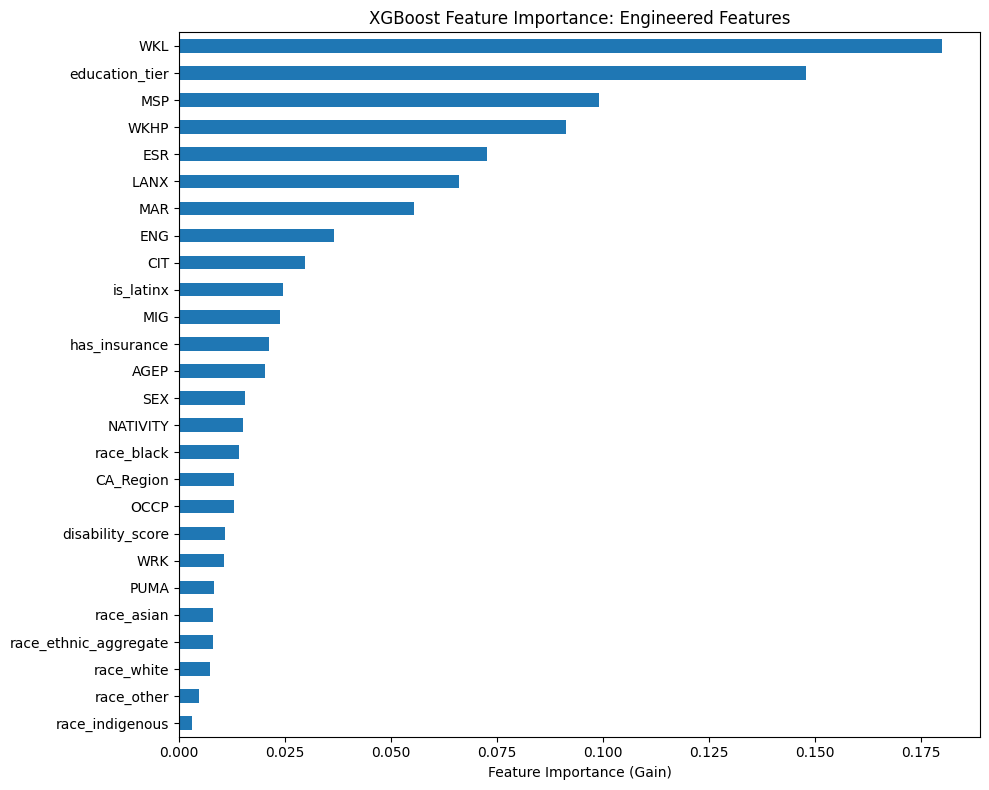

In [22]:
fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('XGBoost Feature Importance: Engineered Features')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/feature_importance_engineered.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
feature_ranking = importance.index.tolist()
results_by_k = []

for k in range(2, len(feature_ranking) + 1):
    top_k = feature_ranking[:k]
    X_tr_k = X_train_us[top_k]
    X_te_k = X_test[top_k]
    model_k = xgb.XGBClassifier(
        objective='binary:logistic', max_depth=6, learning_rate=0.1,
        n_estimators=200, subsample=0.8, colsample_bytree=0.8,
        random_state=42, eval_metric='logloss', early_stopping_rounds=20
    )
    model_k.fit(X_tr_k, y_train_us, eval_set=[(X_te_k, y_test)], verbose=False)
    y_pred_k = model_k.predict(X_te_k)
    f1_k = f1_score(y_test, y_pred_k, average='macro')
    bal_acc_k = balanced_accuracy_score(y_test, y_pred_k)
    results_by_k.append({'k': k, 'macro_f1': f1_k, 'balanced_acc': bal_acc_k, 'features': top_k})
    print(f'  k={k:2d}: Macro F1={f1_k:.4f}, Balanced Acc={bal_acc_k:.4f} | +{feature_ranking[k-1]}')

results_df = pd.DataFrame(results_by_k)

  k= 2: Macro F1=0.6350, Balanced Acc=0.6564 | +education_tier
  k= 3: Macro F1=0.6259, Balanced Acc=0.6941 | +MSP
  k= 4: Macro F1=0.6493, Balanced Acc=0.7146 | +WKHP
  k= 5: Macro F1=0.6583, Balanced Acc=0.7182 | +ESR
  k= 6: Macro F1=0.6594, Balanced Acc=0.7234 | +LANX
  k= 7: Macro F1=0.6598, Balanced Acc=0.7236 | +MAR
  k= 8: Macro F1=0.6654, Balanced Acc=0.7261 | +ENG
  k= 9: Macro F1=0.6684, Balanced Acc=0.7292 | +CIT
  k=10: Macro F1=0.6674, Balanced Acc=0.7297 | +is_latinx
  k=11: Macro F1=0.6683, Balanced Acc=0.7304 | +MIG
  k=12: Macro F1=0.6687, Balanced Acc=0.7310 | +has_insurance
  k=13: Macro F1=0.6813, Balanced Acc=0.7376 | +AGEP
  k=14: Macro F1=0.6830, Balanced Acc=0.7405 | +SEX
  k=15: Macro F1=0.6825, Balanced Acc=0.7402 | +NATIVITY
  k=16: Macro F1=0.6825, Balanced Acc=0.7402 | +race_black
  k=17: Macro F1=0.6839, Balanced Acc=0.7417 | +CA_Region
  k=18: Macro F1=0.6867, Balanced Acc=0.7461 | +OCCP
  k=19: Macro F1=0.6877, Balanced Acc=0.7464 | +disability_score
  

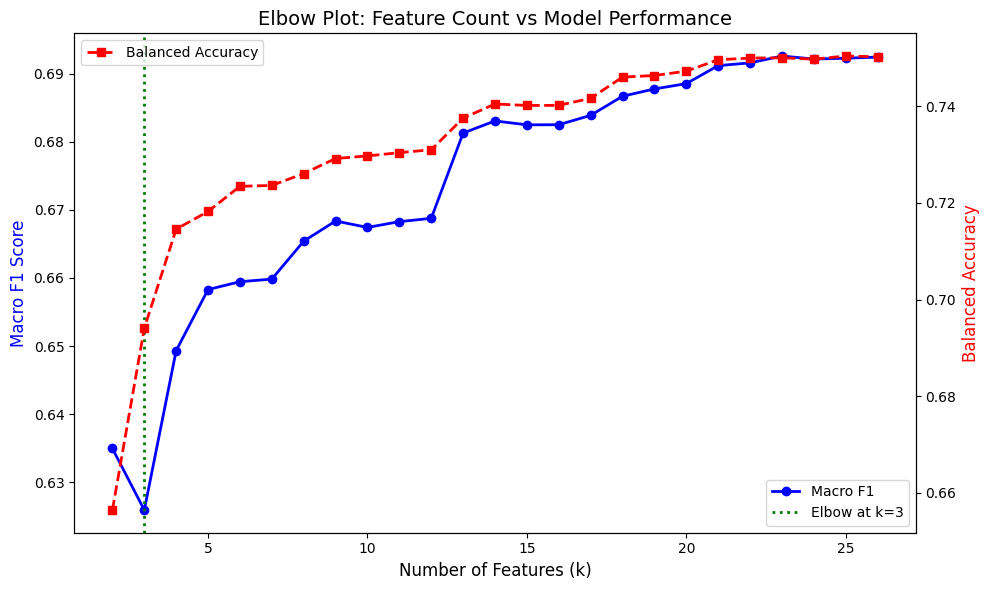

Elbow detected at k=3 features


In [24]:
fig, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(results_df['k'], results_df['macro_f1'], 'b-o', label='Macro F1', linewidth=2)
ax1.set_xlabel('Number of Features (k)', fontsize=12)
ax1.set_ylabel('Macro F1 Score', color='b', fontsize=12)
ax2 = ax1.twinx()
ax2.plot(results_df['k'], results_df['balanced_acc'], 'r--s', label='Balanced Accuracy', linewidth=2)
ax2.set_ylabel('Balanced Accuracy', color='r', fontsize=12)
f1_gains = results_df['macro_f1'].diff()
elbow_idx = f1_gains[f1_gains < 0.005].first_valid_index()
if elbow_idx is not None:
    elbow_k = results_df.loc[elbow_idx, 'k']
    ax1.axvline(x=elbow_k, color='green', linestyle=':', linewidth=2, label=f'Elbow at k={elbow_k}')
ax1.legend(loc='lower right')
ax2.legend(loc='upper left')
plt.title('Elbow Plot: Feature Count vs Model Performance', fontsize=14)
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/elbow_plot_features.png', dpi=150, bbox_inches='tight')
plt.show()
if elbow_idx is not None:
    print(f'Elbow detected at k={elbow_k} features')

  K= 2: Silhouette=0.1407, Inertia=1121897
  K= 3: Silhouette=0.1343, Inertia=1010684
  K= 4: Silhouette=0.1435, Inertia=930748
  K= 5: Silhouette=0.1483, Inertia=879655
  K= 6: Silhouette=0.1558, Inertia=835720
  K= 7: Silhouette=0.1537, Inertia=801165
  K= 8: Silhouette=0.1560, Inertia=773322
  K= 9: Silhouette=0.1446, Inertia=746341
  K=10: Silhouette=0.1401, Inertia=725651
  K=11: Silhouette=0.1549, Inertia=697397
  K=12: Silhouette=0.1501, Inertia=673982
  K=13: Silhouette=0.1508, Inertia=659210
  K=14: Silhouette=0.1512, Inertia=659094


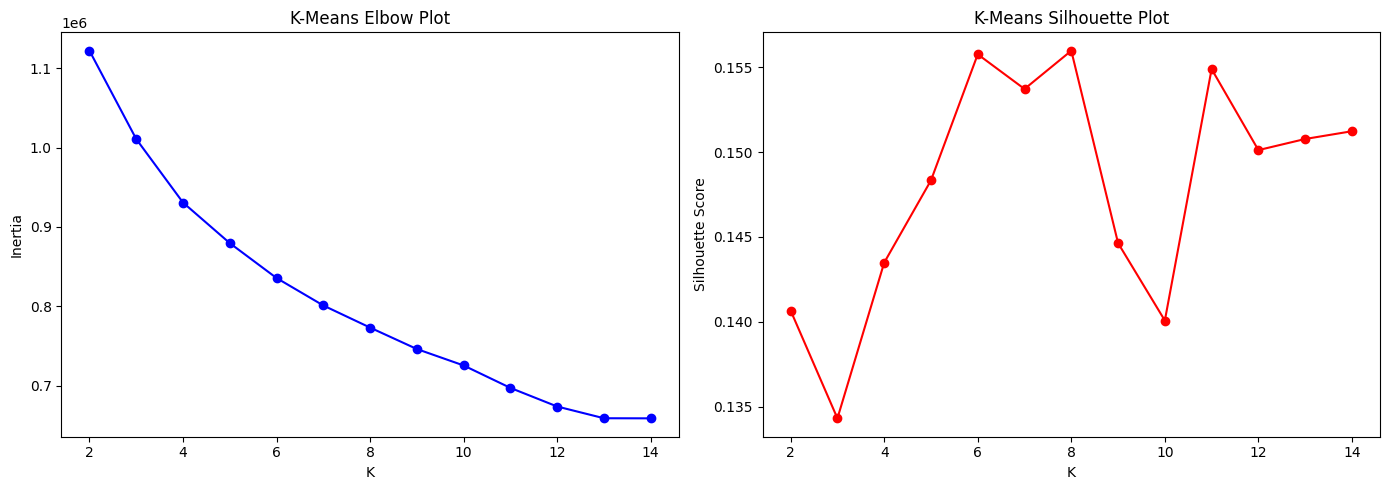

In [25]:
scaler = StandardScaler()
sample_idx = np.random.RandomState(42).choice(len(X_train_us), size=min(50000, len(X_train_us)), replace=False)
X_sample = scaler.fit_transform(X_train_us.iloc[sample_idx])

silhouette_scores = []
inertias = []
K_range = range(2, 15)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=100)
    labels = kmeans.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels, sample_size=10000, random_state=42)
    silhouette_scores.append(sil)
    inertias.append(kmeans.inertia_)
    print(f'  K={k:2d}: Silhouette={sil:.4f}, Inertia={kmeans.inertia_:.0f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(list(K_range), inertias, 'b-o')
ax1.set_xlabel('K'); ax1.set_ylabel('Inertia'); ax1.set_title('K-Means Elbow Plot')
ax2.plot(list(K_range), silhouette_scores, 'r-o')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('K-Means Silhouette Plot')
plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [26]:
best_row = results_df.loc[results_df['macro_f1'].idxmax()]
best_k = int(best_row['k'])
best_f1 = best_row['macro_f1']

threshold = best_f1 - 0.01
parsimonious = results_df[results_df['macro_f1'] >= threshold].iloc[0]
optimal_k = int(parsimonious['k'])
optimal_features = feature_ranking[:optimal_k]

print(f'Best k={best_k} with Macro F1={best_f1:.4f}')
print(f'Most parsimonious k={optimal_k} (within 0.01 of best)')

#include all race/ethnicity variables
race_vars = ['race_white', 'race_black', 'race_asian', 'race_indigenous',
             'race_other', 'is_latinx', 'race_ethnic_aggregate']
added_race = [r for r in race_vars if r not in optimal_features]
optimal_features = optimal_features + added_race

#include SEX and disability_score -- domain-relevant predictors of poverty outcomes
domain_vars = ['SEX', 'disability_score']
added_domain = [d for d in domain_vars if d not in optimal_features]
optimal_features = optimal_features + added_domain

print(f'Force-included {len(added_race)} race/ethnicity variables: {added_race}')
print(f'Domain-included {len(added_domain)} variables: {added_domain}')
print(f'\nFinal feature set ({len(optimal_features)} features):')
for i, f in enumerate(optimal_features, 1):
    if f in added_race:
        marker = ' (race — domain-included)'
    elif f in added_domain:
        marker = ' (domain-included)'
    else:
        marker = ''
    print(f'  {i}. {f}{marker}')

Best k=23 with Macro F1=0.6926
Most parsimonious k=14 (within 0.01 of best)
Force-included 6 race/ethnicity variables: ['race_white', 'race_black', 'race_asian', 'race_indigenous', 'race_other', 'race_ethnic_aggregate']
Domain-included 1 variables: ['disability_score']

Final feature set (21 features):
  1. WKL
  2. education_tier
  3. MSP
  4. WKHP
  5. ESR
  6. LANX
  7. MAR
  8. ENG
  9. CIT
  10. is_latinx
  11. MIG
  12. has_insurance
  13. AGEP
  14. SEX
  15. race_white (race — domain-included)
  16. race_black (race — domain-included)
  17. race_asian (race — domain-included)
  18. race_indigenous (race — domain-included)
  19. race_other (race — domain-included)
  20. race_ethnic_aggregate (race — domain-included)
  21. disability_score (domain-included)


In [ ]:
### why did we end up with k=14 using Macro F1?

# The elbow plot set k=3 as the point where marginal F1 gains per added feature dropped below 0.005, 
# but this was too aggressive because Macro F1 continued to climb meaningfully after that

#The silhouette analysis measures unsupervised cluster separability in the feature space and peaked at k=6
# silhouette scores reflect natural groupings in the data rather than classification performance. It can tell us a lot 
# but its an imperfect guide for our use case, which is a supervised task

# We selected features using Macro F1. The method identifies the best Macro F1 score achieved across all features,
# subtracts a tolerance of 0.01, and selects the smallest k whose performance meets that threshold. 
#This gives us k=14.. the feature set that still performs within 1% of the full model 
## optimizing for the classification task while penalizing unnecessary complexity.

# race, ethnicity, sex and disability_score included for ethical purposes: we don't want to ignore known structural barriers even if they don't meet threshold

## 10) Save Outputs — XGBoost & RF Engineered

In [28]:
import json as _json

df_train.to_csv('preprocessing_data/train_engineered.csv', index=False)
df_test.to_csv('preprocessing_data/test_engineered.csv', index=False)

metadata = {
    'all_features': all_features,
    'engineered_features': engineered_features,
    'kept_features': kept_features,
    'numeric_features': numeric_features,
    'binary_features': binary_features,
    'categorical_features': categorical_features,
    'label_encoder_classes': {col: le.classes_.tolist() for col, le in label_encoders.items()},
    'optimal_features': optimal_features
}
with open('preprocessing_data/feature_engineering_metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2)

print(f'Saved train_engineered.csv: {df_train.shape}')
print(f'Saved test_engineered.csv:  {df_test.shape}')
print(f'Saved feature_engineering_metadata.json')
print(f'Columns in saved CSVs include COW: {"COW" in df_train.columns}')
print(f'Columns in saved CSVs include SCH: {"SCH" in df_train.columns}')

Saved train_engineered.csv: (1490293, 58)
Saved test_engineered.csv:  (308479, 58)
Saved feature_engineering_metadata.json
Columns in saved CSVs include COW: True
Columns in saved CSVs include SCH: True
